In [ ]:
import os
import pickle
import math
import numpy as np
import pandas as pd
import igraph as ig
import networkx as nx  # For drawing capabilities

import datasources
import knots_tools
import viz_tools

import matplotlib
import matplotlib.pyplot as plt

In [2]:
_parsers = {'min_petcount': int, 'ccd_id': int}

_parsers = {
    'chromosome': knots_tools.parse_chromosome,
    'min_petcount': int,
    'ccd_id': int
}
_filters = [
    lambda path, keys: os.path.getsize(path) > 0,  # non-empty files
]

graphs_data_files = datasources.DataSources(
    './results/graphs',
    ['dataset', 'chromosome', 'ccd_id']
).add(  # Raw input graphs (hg38) in cknots format
    'graph_file', r'ccd_graph_(?P<dataset>\w+)_(?P<chromosome>\w+)_(?P<ccd_id>\d+)\.pickle$',
    parsers=_parsers, filters=_filters
).get_paths_as_dataframe()
graphs_data_files

graph_file
dataset chromosome ccd_id                                                  
GM12878 chr1       1       ./results/graphs/ccd_graph_GM12878_chr1_1.pickle
                   2       ./results/graphs/ccd_graph_GM12878_chr1_2.pickle
                   3       ./results/graphs/ccd_graph_GM12878_chr1_3.pickle
                   4       ./results/graphs/ccd_graph_GM12878_chr1_4.pickle
                   5       ./results/graphs/ccd_graph_GM12878_chr1_5.pickle
...                                                                     ...
WTC11   chr9       39       ./results/graphs/ccd_graph_WTC11_chr9_39.pickle
                   40       ./results/graphs/ccd_graph_WTC11_chr9_40.pickle
                   41       ./results/graphs/ccd_graph_WTC11_chr9_41.pickle
        chrX       1         ./results/graphs/ccd_graph_WTC11_chrX_1.pickle
                   2         ./results/graphs/ccd_graph_WTC11_chrX_2.pickle

[9101 rows x 1 columns]

In [3]:
def _read_graph(path):
    # Save the variable g to the pickle file
    with open(path, 'rb') as f:
        g = pickle.load(f)
    return g

_my_dataset = 'GM12878'
_my_chromosome = 'chr10'
_my_ccd_id = 64

example_graph = _read_graph(graphs_data_files.loc[_my_dataset, _my_chromosome, _my_ccd_id].graph_file)
example_graph.summary()

'IGRAPH U--- 84 143 -- \n+ attr: betweenness (v), closeness (v), coord (v), degree (v), idx_in_minor (v), minors (v), distance (e), edge_betweenness (e), idx_in_minor (e), is_contact (e), is_strand (e), loop_count (e), loop_ids (e), minors (e), petcount (e)'

In [4]:
def _get_edges(g: ig.Graph, minor_only: bool):    
    for e in g.es():
        if not e['is_contact']:
            continue
        if (len(e['minors']) == 0) == minor_only:
            continue
        u, v = e.source, e.target
        yield u, v, g.vs[u]['coord'], g.vs[v]['coord'], float(e['petcount'])

def _minor_edges(g, minor_only=True):
    _tmp = pd.DataFrame.from_records(_get_edges(g, minor_only))
    _tmp.columns = ['node_id_A', 'node_id_B', 'coord_A', 'coord_B', 'weight']
    return _tmp

_minor_edges(example_graph) #.to_csv('~/Downloads/hg38_chr10_ccd64_small.csv')

,node_id_A,node_id_B,coord_A,coord_B,weight
0,0,52,86397506,86511955,3.0
1,2,22,86405033,86451247,4.0
2,4,54,86406781,86514248,7.0
3,6,74,86409093,86559606,3.0
4,12,58,86429315,86523354,3.0
5,16,40,86435439,86483148,4.0
6,20,76,86445945,86562048,3.0
7,26,56,86458088,86517034,3.0
8,32,60,86469663,86527621,3.0
9,34,64,86475004,86531440,3.0


In [5]:
print(f'chr10:{_minor_edges(example_graph, False).coord_A.min() - 20000}-{_minor_edges(example_graph, False).coord_B.max() + 20000}')

chr10:86377506-86602990


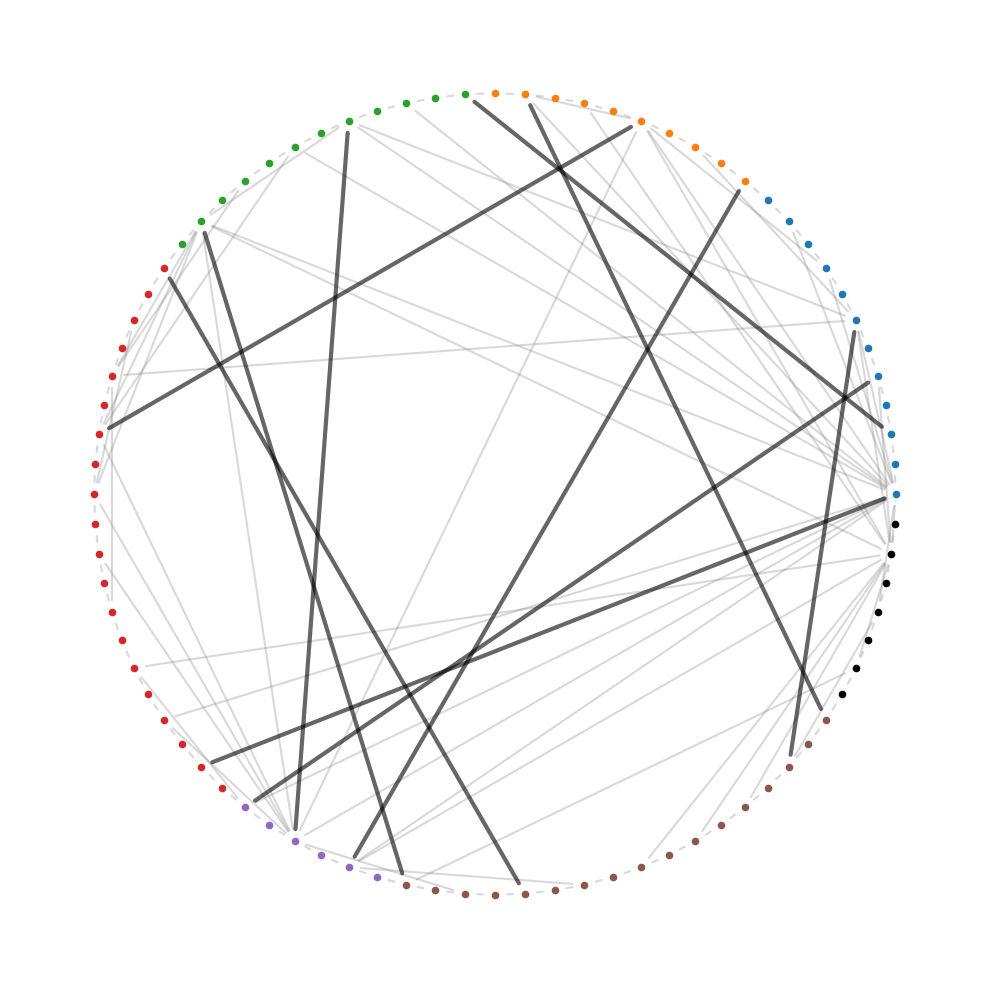

In [7]:
plt.figure(figsize=(10, 10))
minor = viz_tools.draw_graph_with_minor(example_graph, layout='circular', rad=None, draw_strands=True)
# plt.title(f'|V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}', fontsize=14)
plt.tight_layout()
plt.show()
# plt.savefig('./results/plots/example_graph_circle.png')
# plt.savefig('./results/plots/example_graph_circle.svg')

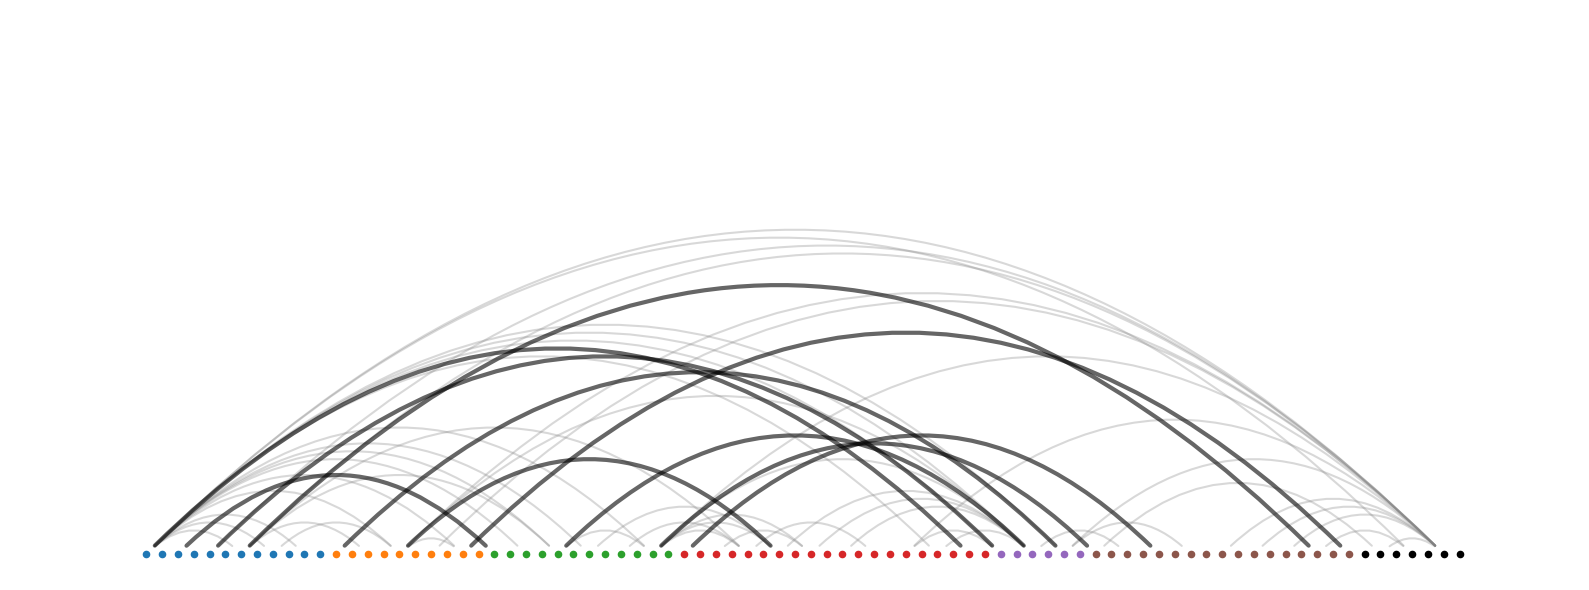

In [8]:
plt.figure(figsize=(16, 6))
minor = viz_tools.draw_graph_with_minor(example_graph)
# plt.title(f'|V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}', fontsize=14)
plt.tight_layout()
plt.show()
# plt.savefig('./results/plots/example_graph_line.png')
# plt.savefig('./results/plots/example_graph_line.svg')

## Schematics for the manuscript

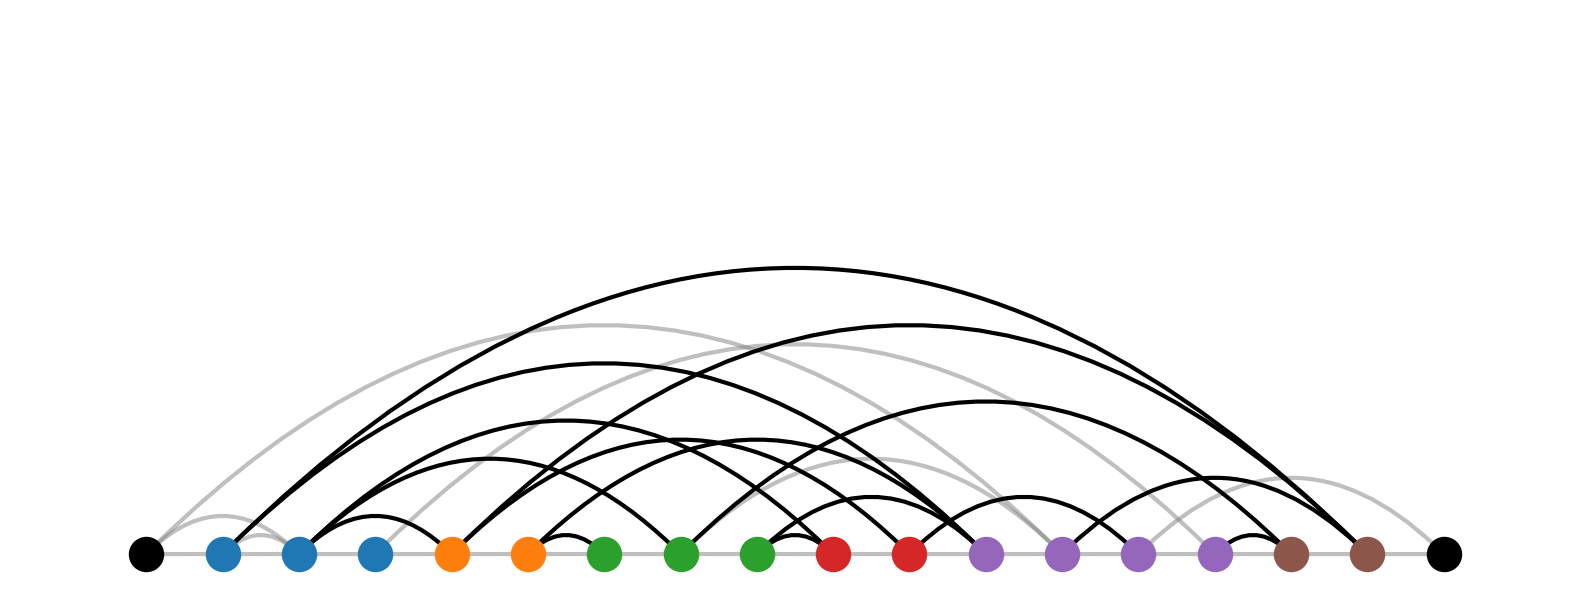

In [10]:
G = nx.MultiDiGraph()
for u, g in enumerate(
    [-1, 0, 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 4, 5, 5, -1],
):
    G.add_node(u, group_idx=g, coord=u * 100_000 + 100_000_000)
n = G.number_of_nodes()
for u, v in zip(range(
    n - 1), range(1, n)):
    G.add_edge(u, v, is_contact=False, is_strand=True, idx_in_minor=0, petcount=1)   
# [1, 2, 3], [4, 5], [6, 7, 8], [9, 10], [11, 12, 13, 14], [15, 16]
for u, v in [
    (2, 4), (2, 7), (2, 9), (1, 11), (1, 16),  # 1
    (5, 6), (4, 10), (5, 11), (4, 16),  # 2
    (8, 9), (8, 11), (7, 15), # 3
    (10, 13), (12, 16),  # 4
    (14, 15)  # 5
]:
    G.add_edge(u, v, is_contact=True, is_strand=False, idx_in_minor=(0, 0))
for u, v in [
    (0, 2), (0, 12), (1, 2), (3, 14), (7, 12), (13, 17)
]:
    G.add_edge(u, v, is_contact=True, is_strand=False, idx_in_minor=tuple())

plt.figure(figsize=(16, 6))
viz_tools.draw_graph_with_minor(G, draw_strands=True, node_size=600,
                      arc_alpha=0.5, selected_arc_alpha=1,
                      arc_linewidth=3.0, selected_arc_linewidth=3.0)
plt.tight_layout()
# plt.show()
# plt.savefig('./results/plots/graph_schema.svg')

## 3D Model

In [11]:
print(minor.chromosome)
print(minor.coordinates)
print('************ SEGMENTS:')
for seg in minor.segments:
    print(seg)
# print m.nodes # m.nodes iterates over all nodes
print('************ EDGES:')
print(list(minor.edges.items()))

chr10
(86397506, 86562048)
************ SEGMENTS:
range(0, 12)
range(12, 22)
range(22, 34)
range(34, 54)
range(54, 60)
range(60, 77)
************ EDGES:
[((0, 3), (0, 52)), ((0, 2), (2, 22)), ((0, 4), (4, 54)), ((0, 5), (6, 74)), ((1, 4), (12, 58)), ((1, 3), (16, 40)), ((1, 5), (20, 76)), ((2, 4), (26, 56)), ((2, 5), (32, 60)), ((3, 5), (34, 64))]


In [47]:
def gen_restraints(graph, resolution, pad = 0, bounds = None):
    assert pad >= 0
    assert bounds is None or bounds[0] < bounds[1]
    node_coords = np.array(list(nx.get_node_attributes(graph, 'coord').values()))
    if bounds is not None:
        min_coord = bounds[0] - pad
        max_coord = bounds[1] + pad
    else:
        min_coord = node_coords[0] - pad - resolution // 2
        max_coord = node_coords[-1] + pad + resolution // 2
    bead_coords = np.arange(min_coord, max_coord, resolution)
    bead_index = (node_coords - min_coord) // resolution

    groups = []
    current_group = -1
    start = -1
    end = -1
    for bi, (_, gi) in zip(bead_index, graph.nodes(data='group_idx')):
        if gi != current_group:
            if current_group != -1:
                groups.append((start, end, current_group))
            current_group = gi
            start = bi
        end = bi

    restraints = pd.DataFrame.from_records(
        (bead_index[u], bead_index[v])
        for u, v, data in graph.edges(data=True)
        if (
            data['is_contact']\
            and data['idx_in_minor']\
            and node_coords[u] >= min_coord and node_coords[u] <= max_coord\
            and node_coords[v] >= min_coord and node_coords[v] <= max_coord
        )
    )
    restraints.columns = ['ibead1', 'ibead2']
    restraints = restraints.drop_duplicates()
    restraints = restraints.sort_values(['ibead1', 'ibead2'])
    return bead_coords, restraints, groups

nx_graph = G
# nx_graph = example_graph.to_networkx()
resolution = 1000
padding = 10000
bead_coords, restraints, groups = gen_restraints(nx_graph, resolution, padding)
n_beads = len(bead_coords)
print(f'n_beads = {n_beads}')
print(bead_coords[:5])
print(groups)
restraints.head(3)

n_beads = 1721
[99989500 99990500 99991500 99992500 99993500]
[(110, 310, 0), (410, 510, 1), (610, 810, 2), (910, 1010, 3), (1110, 1410, 4), (1510, 1610, 5)]


,ibead1,ibead2
0,110,1110
1,110,1610
2,210,410


In [13]:
def save_rst(df, path):
    df2 = df.apply(lambda col: ':' + col.astype(str))
    df2.to_csv(path, sep='\t', index=False, header=False)

def save_coloring(groups, path, colors):
    with open(path, 'w') as f:
        f.write(f'open min_str.pdb\n')
        f.write(f'background solid white\n')
        f.write(f'color #878787 :.A\n')
        for start, end, gi in groups:
            color = matplotlib.colors.to_hex(colors[gi])
            f.write(f'color {color} :{start}-{end}\n')

_model_name = 'synthetic'
models_dir = os.path.join('./models', _model_name)
os.makedirs(models_dir, exist_ok=True)
restraints_file = os.path.join(models_dir, f'restraints.rst')
save_rst(restraints, restraints_file)
palette = sns.color_palette('tab10', 6)
save_coloring(groups, os.path.join(models_dir, 'prepare_model.cmd'), palette)
palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)]

In [48]:
init_str_file = os.path.join(models_dir, f'init_str.pdb')
!../mkadlof-structuregenerator/generator.py self_avoiding_random_walk $n_beads -o $init_str_file

100%|██████████████████████████████████████| 1720/1720 [00:04<00:00, 362.96it/s]
File ./models/test/init_str.pdb saved...


In [49]:
!cp spring_model_config.ini $models_dir/config.ini
!./run_sm_docker.sh $models_dir

Spring model - in house version.
OpenMM version: 8.0
Reading config...
Automatically generated config file saved in config_auto.ini
Initialization...
   Loading initial structure: ../model/init_str.pdb
   Loading forcefield file:  forcefields/polymer_1kb_ff.xml
   Building system...
   Adding forces...
      Adding harmonic bonds...
         r0 = 0.1 nm
         k = 300000.0 kJ/mol/nm^2
         1720 harmonic bonds added.
      Adding harmonic angles...
         r0 = 3.141592653589793
         k = 10.0 kJ/mol/radian^2
         1719 harmonic bonds added.
      Adding excluded volume...
         epsilon = 2.86
         sigma = 0.05 nm
         1721 ev interactions added.
      Adding harmonic restraints
         15 restraints added.
   Integrator initialization...
   Setting up simulation...
      Simulation will run on platform: CUDA
Energy minimizing...
  Saving minimized structure in ../model/min_str.pdb

Final frame potential energy components
Harmonic bonds    : 812217.50 kJ/mol (13

##  Test structure

|V|=30, |E|=15
|V|=30, |E|=44


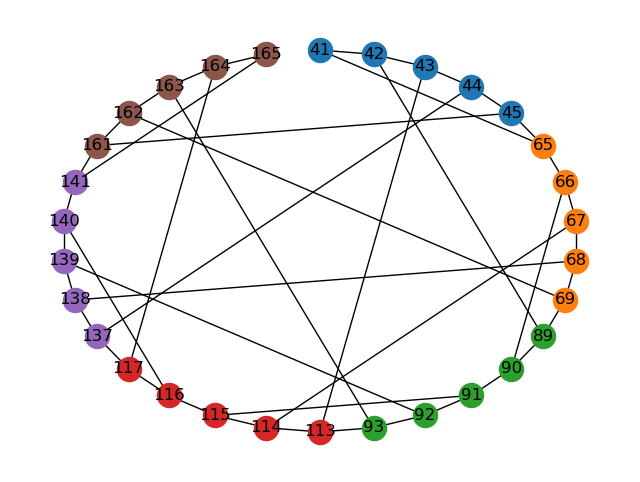

In [16]:
resolution = 1000
padding = 20000

clique_size = 6
_nodes = [
    (i, j)
    for i in range(clique_size)
    for j in range(clique_size) if i != j
]
_edges = [
    ((i, j), (j, i))
    for i in range(clique_size)
    for j in range(i + 1, clique_size)
]
_strand_edges = list(zip(_nodes[:-1], _nodes[1:]))
test_graph = nx.Graph()
test_graph.add_nodes_from(_nodes)
test_graph.add_edges_from(_edges, is_strand=False, is_contact=True)
print(f'|V|={test_graph.number_of_nodes()}, |E|={test_graph.number_of_edges()}')
test_graph.add_edges_from(_strand_edges, is_strand=True, is_contact=False)
print(f'|V|={test_graph.number_of_nodes()}, |E|={test_graph.number_of_edges()}')

nx.set_node_attributes(test_graph, {u: u[0] for u in test_graph.nodes()}, 'group_idx')
# nx.set_node_attributes(test_graph,{
#     u: padding + resolution + beads_per_segment * resolution * i for i, u in enumerate(test_graph.nodes())
# }, 'coord')
_small_sep = 1000
_big_sep = 20000
coord = padding + _big_sep
for i, j in test_graph.nodes():
    coord += _big_sep if j == 0 else _small_sep
    test_graph.nodes[(i, j)]['coord'] = coord

nx.set_edge_attributes(test_graph, True, 'idx_in_minor')

# print(test_graph.nodes(data=True))
# print(test_graph.edges(data=True))
r = 1.0
max_u = test_graph.number_of_nodes()
pos = {
    u: (r * math.sin(2 * math.pi * i / max_u), r * math.cos(2 * math.pi * i / max_u))
    for i, u in enumerate(test_graph.nodes())
}
# nx.draw(test_graph, pos=pos, labels={(i, j): f'{i}-{j}' for (i, j), c in test_graph.nodes(data='coord')})
fig = plt.gcf()
fig.set_size_inches(8, 6)
for i in range(clique_size):
    nx.draw_networkx_nodes(test_graph, pos, [u for u in test_graph.nodes() if u[0] == i], node_color=_node_colors[i])
nx.draw_networkx_labels(test_graph, pos, labels={(i, j): f'{c // resolution}' for (i, j), c in test_graph.nodes(data='coord')})
nx.draw_networkx_edges(test_graph, pos)
clear_ax(plt.gca())

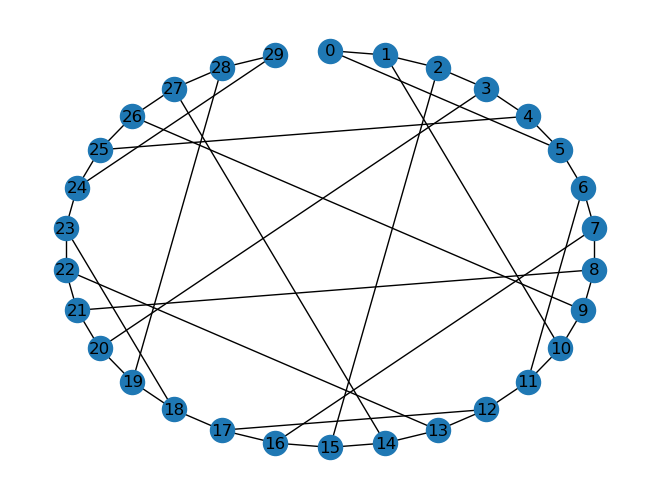

In [17]:
g2 = nx.relabel_nodes(test_graph, {u: i for i, u in enumerate(test_graph.nodes())}, copy=True)
pos = {
    u: (r * math.sin(2 * math.pi * i / max_u), r * math.cos(2 * math.pi * i / max_u))
    for i, u in enumerate(g2.nodes())
}
nx.draw(g2, pos=pos, labels={u: f'{u}' for u in g2.nodes()})

In [29]:
bead_coords, restraints, groups = gen_restraints(g2, resolution, padding)
n_beads = len(bead_coords)
print(f'n_beads = {n_beads}')
print(bead_coords[:5])
print(groups)
restraints

n_beads = 165
[20500 21500 22500 23500 24500]
[(20, 24, 0), (44, 48, 1), (68, 72, 2), (92, 96, 3), (116, 120, 4)]


,ibead1,ibead2
0,20,44
1,21,68
2,22,92
3,23,116
4,24,140
5,45,69
6,46,93
7,47,117
8,48,141
9,70,94
